# Chapter 2: Continuity

**Source span:** Armstrong, *Basic Topology*, Chapter 2, printed pp. 27-42, PDF pp. 38-53.

**Chapter question:** how can continuity be recognized from inverse images, neighborhoods, and closures rather than from the visual smoothness of a graph?

The chapter starts by rebuilding topology from open sets, then uses that language to define continuous maps. The computational version below treats an open set as a test that should pull back to an open test in the domain. That one idea explains why restrictions are harmless, why a circle seam can break an inverse map, why space-filling curves do not contradict continuity, and why metric spaces have enough distance functions to extend real-valued data from closed subsets.


## Computational Translation Guide

| Topological phrase | Computational model in this notebook | What the check can and cannot prove |
| --- | --- | --- |
| Open set | A predicate with room around each accepted point, often represented by a shaded region with a positive radius witness | A finite drawing cannot prove openness globally, but it can expose the local witness the definition asks for. |
| Closed set | Complement is open; equivalently the set contains its limit points | Symbolic interval checks and sampled frontier checks catch the boundary behavior in the examples. |
| Subspace topology | Intersect ambient open sets with the chosen subspace | The same subset can become open, closed, both, or neither after the ambient space changes. |
| Continuity | Pull every open target test back to an open domain test | We test representative bases, then connect the test to the closure and closed-set criteria. |
| Quotient or seam behavior | Compare a parametrized interval with a circle where endpoints want to be identified | A continuous bijection can fail to be a homeomorphism when the inverse mishandles the seam. |
| Space-filling curve | A sequence of finer polygonal stages whose mesh size tends to zero | The finite stages show the coverage mechanism; the theorem still needs compactness and closure, which arrive later. |
| Extension from a closed set | Use metric distance to separate closed sets and build controlled real-valued functions | Distance calculations provide a concrete scaffold for the Tietze extension theorem. |


In [1]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import sympy as sp
from IPython.display import display
from matplotlib.patches import Circle, Rectangle
from PIL import Image

WORKSPACE_ROOT = Path.cwd()
BOOK_ROOT = WORKSPACE_ROOT / "Basic-Topology"
if not BOOK_ROOT.exists():
    BOOK_ROOT = Path("..").resolve()
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import (
    artifact_path,
    assert_artifact,
    display_artifact,
    save_json,
    save_matplotlib,
    save_plotly_html,
)

UNIT = "chapter-02"
NOTEBOOK_PATH = BOOK_ROOT / "chapter-02-continuity" / "02-continuity.ipynb"

plt.rcParams.update(
    {
        "figure.figsize": (8, 5),
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 10,
    }
)

created_artifacts: list[Path] = []
artifact_min_bytes: dict[str, int] = {}


def remember(path: Path, min_bytes: int = 512) -> Path:
    created_artifacts.append(path)
    artifact_min_bytes[path.as_posix()] = min_bytes
    return path


def save_current_figure(filename: str, min_bytes: int = 8_000) -> Path:
    path = save_matplotlib(plt.gcf(), UNIT, "figures", filename)
    plt.close(plt.gcf())
    return remember(path, min_bytes)


## Visual Storyboard Logic

| Sequence | Concept | Representation and library | Artifact | Inspection target | Validation |
| --- | --- | --- | --- | --- | --- |
| 1 | Open, closed, interior, frontier, subspace topology | Matplotlib regions plus a small table | `figures/open-closed-frontier.png`, `tables/open-closed-frontier-table.csv` | Boundary points are exactly where open-ball witnesses fail or complements change | Sampled frontier radius and a clopen subspace flag |
| 2 | Continuity through preimages and equivalent tests | Matplotlib preimage bands, NetworkX implication graph, SymPy interval algebra | `figures/preimage-continuity-test.png`, `figures/concept-dependency-map.png` | Open target tests pull back to open domain pieces for a continuous map, but not for a jump | Exact preimage inequalities for `x^2`; graph cycle check |
| 3 | Circle seam and quotient intuition | Matplotlib circle and interval comparison | `figures/circle-seam-preimage.png` | A seam-crossing arc has an open preimage in `[0,1)`, while the inverse map fails at the seam | A sequence approaches the circle seam while inverse parameters do not approach `0` |
| 4 | Space-filling curve intuition | Hilbert-stage static plot and Plotly stage selector | `figures/space-filling-curve-stage.png`, `html/space-filling-stages.html` | Each stage visits every grid cell and the coverage radius decreases | Coverage radius decreases by a factor of `1/2` per stage |
| 5 | Metric separation and extension | Matplotlib distance separator and explicit one-dimensional extension; SymPy series check | `figures/metric-separation-extension.png`, `checks/metric-separation-extension-checks.json` | Distances to closed sets create continuous separators and extension control | Separator values on closed sets, distance Lipschitz check, and exact Tietze series sum |


## Open And Closed Sets As Local Tests

An open set is not just a shaded region. It is a region where each accepted point has some room to move without leaving. A closed set is not merely a region with a boundary drawn in; it is a set whose outside is open, or equivalently a set that already contains the limit points forced by nearby samples.

The subspace topology is the first place where visual intuition needs discipline. A component that is not open in the whole plane can be open inside a smaller space because the allowed nearby points have changed. The right-hand panel below uses a two-component subspace of the plane to show a subset that is both open and closed in that subspace.


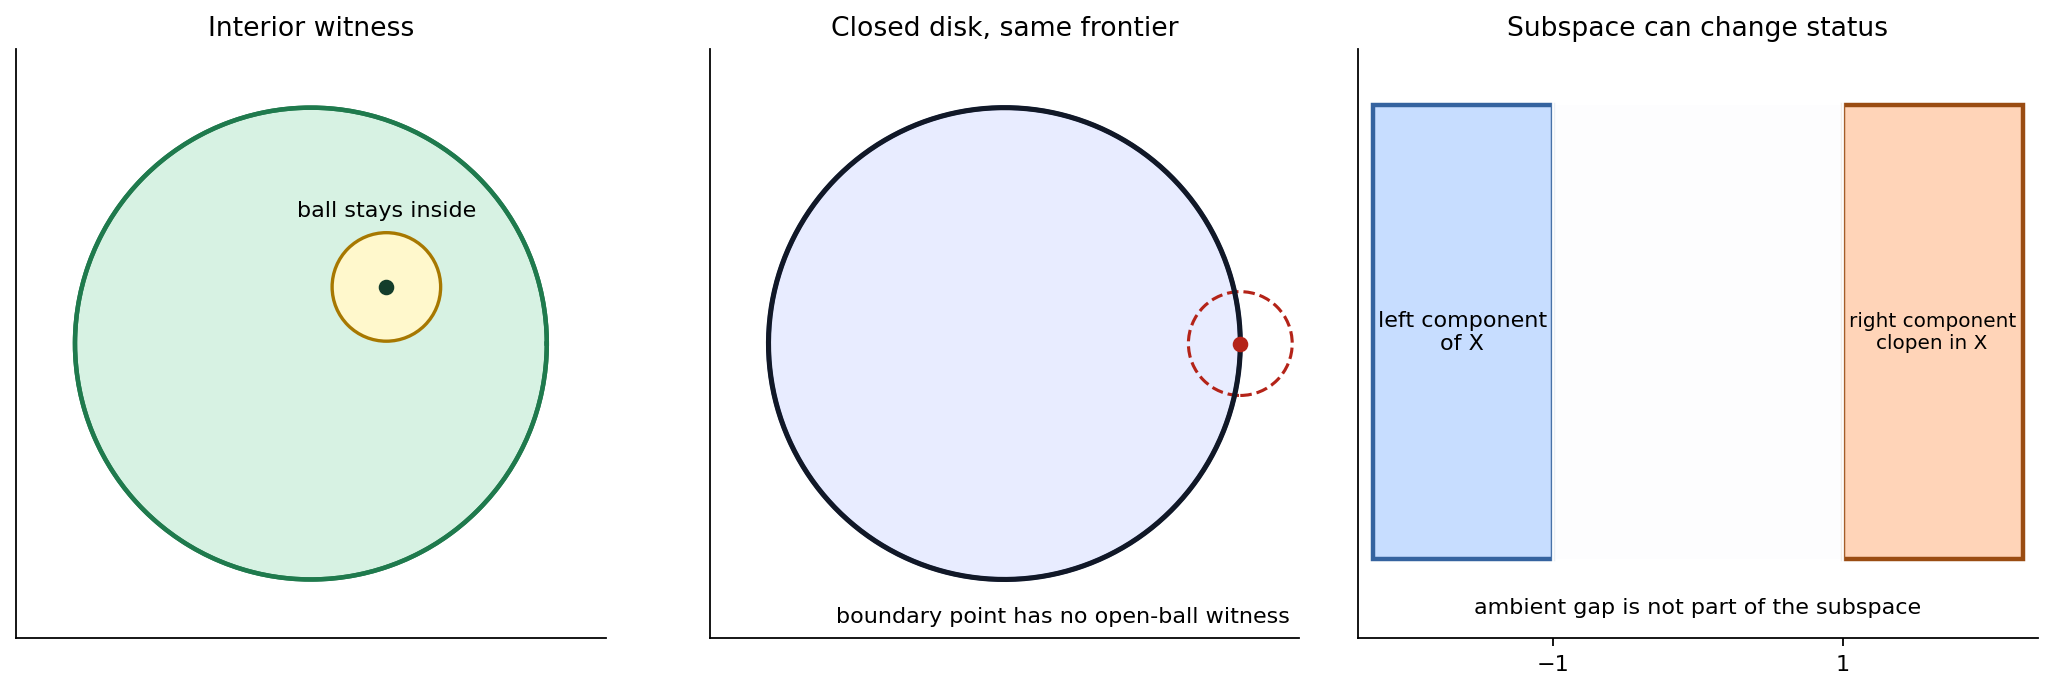

,example,interior,closure,frontier,open?,closed?
0,open unit disk in R^2,itself,closed unit disk,unit circle,True,False
1,closed unit disk in R^2,open unit disk,itself,unit circle,False,True
2,right component of X = {x <= -1} union {x >= 1},itself in the subspace X,itself in the subspace X,empty in X,True,True


In [2]:
theta = np.linspace(0, 2 * np.pi, 512)
circle_x, circle_y = np.cos(theta), np.sin(theta)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), constrained_layout=True)

ax = axes[0]
ax.add_patch(Circle((0, 0), 1, facecolor="#d7f2e3", edgecolor="#1f7a4d", lw=2))
ax.add_patch(Circle((0.32, 0.24), 0.23, facecolor="#fff8cc", edgecolor="#a77800", lw=1.5))
ax.plot(circle_x, circle_y, color="#1f7a4d", lw=2)
ax.scatter([0.32], [0.24], color="#143d2b", zorder=3)
ax.text(0.32, 0.54, "ball stays inside", ha="center")
ax.set_title("Interior witness")
ax.set_aspect("equal")
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_xticks([])
ax.set_yticks([])

ax = axes[1]
ax.add_patch(Circle((0, 0), 1, facecolor="#e8ecff", edgecolor="#2f4ea2", lw=2))
ax.plot(circle_x, circle_y, color="#111827", lw=2.3, label="frontier")
ax.scatter([1], [0], color="#b42318", zorder=3)
ax.add_patch(Circle((1, 0), 0.22, facecolor="none", edgecolor="#b42318", lw=1.4, ls="--"))
ax.text(0.25, -1.18, "boundary point has no open-ball witness", ha="center")
ax.set_title("Closed disk, same frontier")
ax.set_aspect("equal")
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)
ax.set_xticks([])
ax.set_yticks([])

ax = axes[2]
ax.add_patch(Rectangle((-2.25, -1.0), 4.5, 2.0, facecolor="#f3f4f6", edgecolor="none"))
ax.add_patch(Rectangle((-2.25, -1.0), 1.25, 2.0, facecolor="#c7ddff", edgecolor="#35639f", lw=2))
ax.add_patch(Rectangle((1.0, -1.0), 1.25, 2.0, facecolor="#ffd4b8", edgecolor="#9a4c12", lw=2))
ax.axvspan(-1.0, 1.0, color="white", alpha=0.9)
ax.text(-1.63, 0, "left component\nof X", ha="center", va="center")
ax.text(1.62, 0, "right component\nclopen in X", ha="center", va="center", fontsize=9)
ax.text(0, -1.24, "ambient gap is not part of the subspace", ha="center")
ax.set_title("Subspace can change status")
ax.set_xlim(-2.35, 2.35)
ax.set_ylim(-1.35, 1.25)
ax.set_xticks([-1, 1])
ax.set_yticks([])

frontier_path = save_current_figure("open-closed-frontier.png")

frontier_table = pd.DataFrame(
    [
        {
            "example": "open unit disk in R^2",
            "interior": "itself",
            "closure": "closed unit disk",
            "frontier": "unit circle",
            "open?": True,
            "closed?": False,
        },
        {
            "example": "closed unit disk in R^2",
            "interior": "open unit disk",
            "closure": "itself",
            "frontier": "unit circle",
            "open?": False,
            "closed?": True,
        },
        {
            "example": "right component of X = {x <= -1} union {x >= 1}",
            "interior": "itself in the subspace X",
            "closure": "itself in the subspace X",
            "frontier": "empty in X",
            "open?": True,
            "closed?": True,
        },
    ]
)
table_path = artifact_path(UNIT, "tables", "open-closed-frontier-table.csv")
frontier_table.to_csv(table_path, index=False)
remember(table_path, 256)

boundary_radii = np.sqrt(circle_x**2 + circle_y**2)
open_closed_checks = {
    "sampled_unit_circle_radius_error_max": float(np.max(np.abs(boundary_radii - 1))),
    "subspace_right_component_open_in_X": True,
    "subspace_right_component_closed_in_X": True,
    "frontier_table_rows": int(len(frontier_table)),
}
open_closed_check_path = save_json(open_closed_checks, UNIT, "checks", "open-closed-frontier-checks.json")
remember(open_closed_check_path, 128)

assert open_closed_checks["sampled_unit_circle_radius_error_max"] < 1e-12
assert open_closed_checks["subspace_right_component_open_in_X"]
assert_artifact(frontier_path, min_bytes=artifact_min_bytes[frontier_path.as_posix()])
assert_artifact(table_path, min_bytes=artifact_min_bytes[table_path.as_posix()])
display_artifact(frontier_path, width=900)
display(frontier_table)


## Continuity By Preimages

The open-set definition turns continuity into a contravariant test: inspect a target open set, then pull it back to the domain. The point is not that every drawing of a continuous function looks smooth. The point is that target neighborhoods do not create sudden closed endpoints or isolated failures when viewed upstairs in the domain.

The first panel below uses `f(x)=x^2`. An open target band pulls back to two open intervals. The second panel uses a jump map, where an open target band pulls back to a half-line with its endpoint included, so the preimage fails to be open. The graph next to it records the theorem-level logic: open preimages, base tests, closure behavior, and closed preimages are equivalent continuity tests.


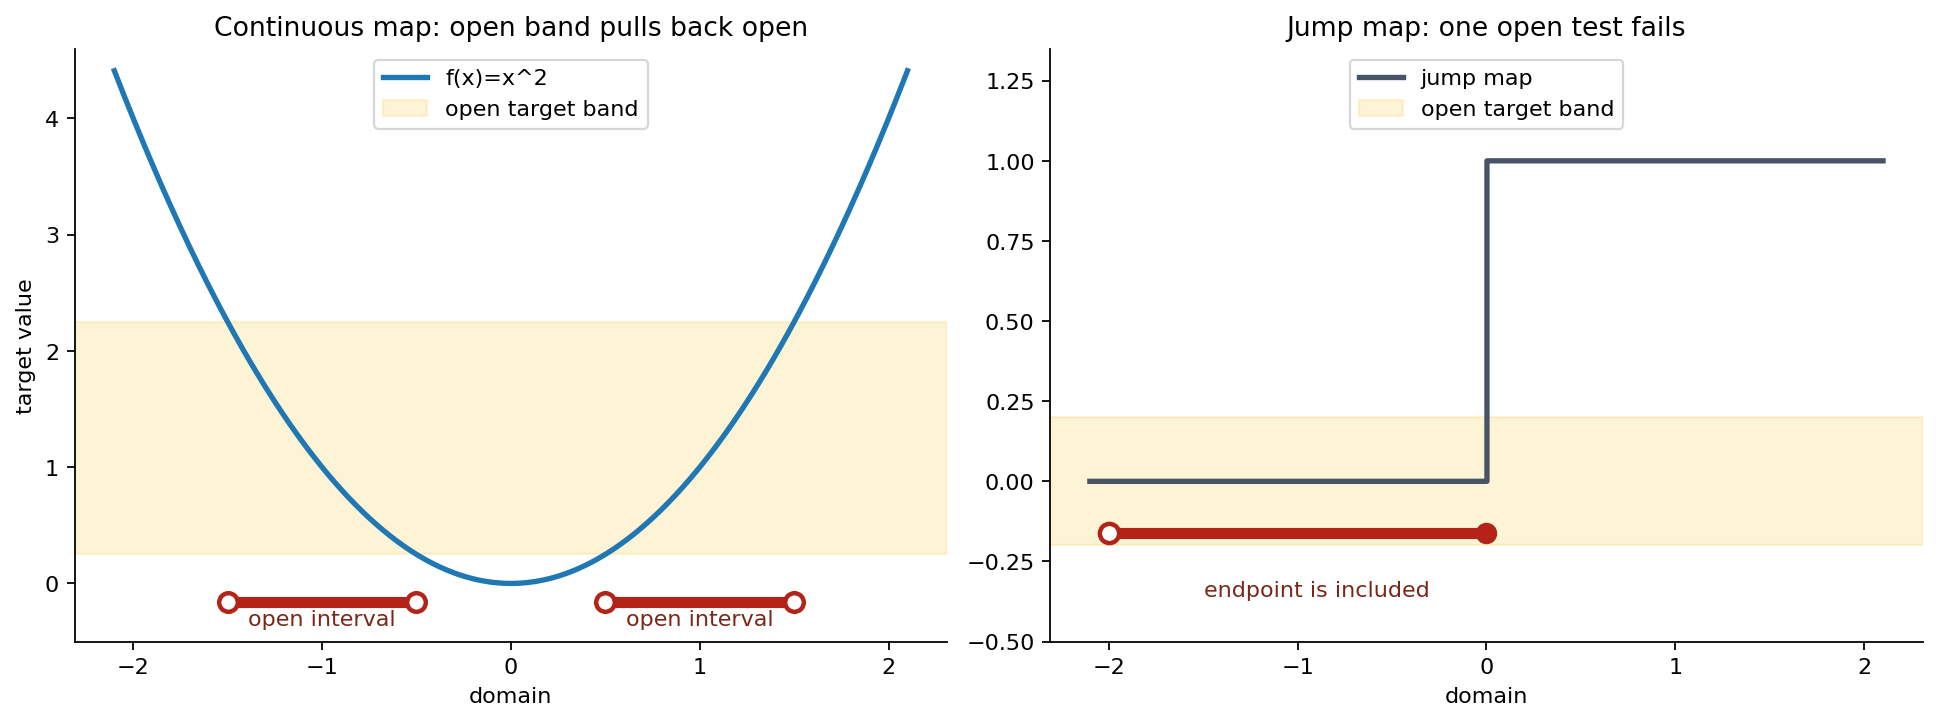

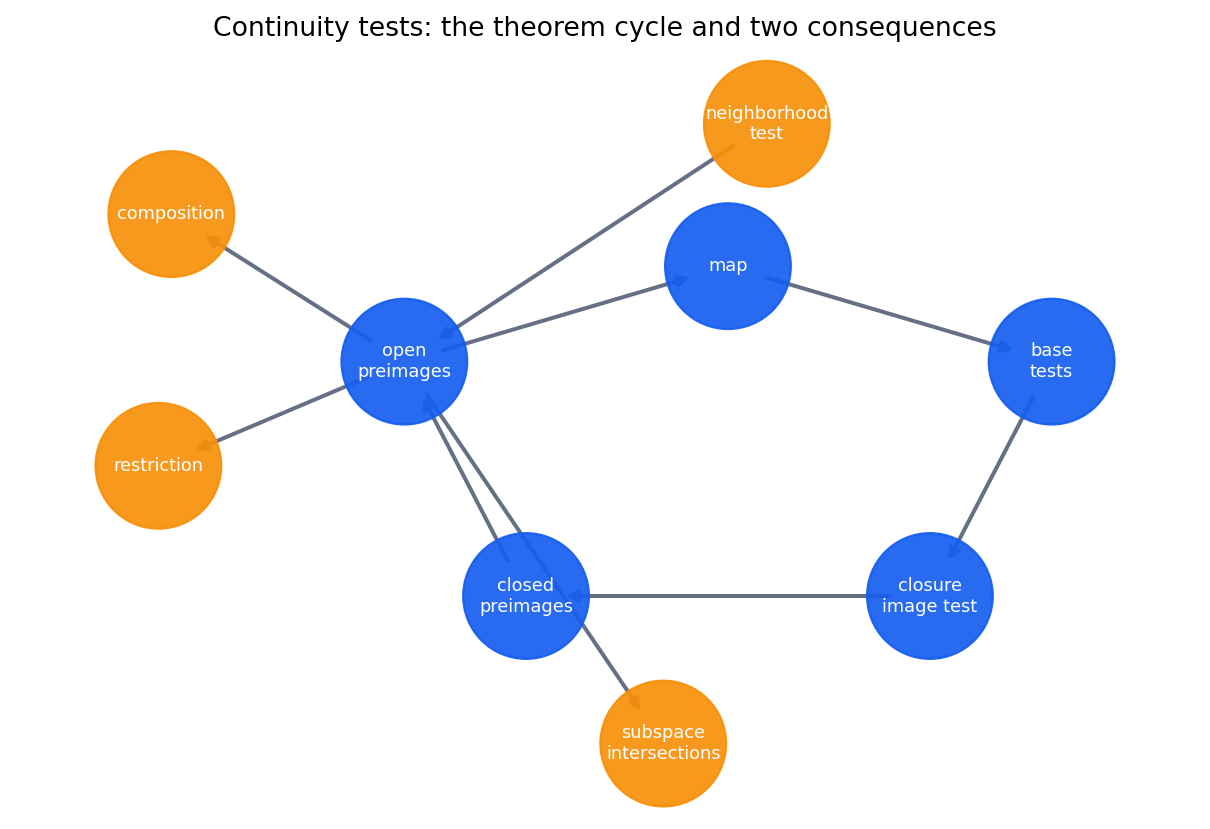

In [3]:
x = sp.symbols("x", real=True)
open_preimage_condition = sp.reduce_inequalities(
    [x**2 > sp.Rational(1, 4), x**2 < sp.Rational(9, 4)], x
)
closed_preimage_condition = sp.reduce_inequalities([x**2 <= sp.Rational(1, 4)], x)

xx = np.linspace(-2.1, 2.1, 800)
y_square = xx**2
jump = np.where(xx <= 0, 0.0, 1.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)

ax = axes[0]
ax.plot(xx, y_square, color="#1f77b4", lw=2.4, label="f(x)=x^2")
ax.axhspan(0.25, 2.25, color="#f8d568", alpha=0.28, label="open target band")
for a, b in [(-1.5, -0.5), (0.5, 1.5)]:
    ax.plot([a, b], [-0.16, -0.16], color="#b42318", lw=5, solid_capstyle="round")
    ax.scatter([a, b], [-0.16, -0.16], s=70, facecolors="white", edgecolors="#b42318", lw=2, zorder=4)
ax.text(-1.0, -0.36, "open interval", ha="center", color="#7a271a")
ax.text(1.0, -0.36, "open interval", ha="center", color="#7a271a")
ax.set_title("Continuous map: open band pulls back open")
ax.set_xlabel("domain")
ax.set_ylabel("target value")
ax.set_ylim(-0.5, 4.6)
ax.legend(loc="upper center")

ax = axes[1]
ax.plot(xx, jump, color="#475467", lw=2.4, drawstyle="steps-post", label="jump map")
ax.axhspan(-0.2, 0.2, color="#f8d568", alpha=0.28, label="open target band")
ax.plot([-2.0, 0], [-0.16, -0.16], color="#b42318", lw=5, solid_capstyle="butt")
ax.scatter([0], [-0.16], s=75, color="#b42318", zorder=4)
ax.scatter([-2.0], [-0.16], s=75, facecolors="white", edgecolors="#b42318", lw=2, zorder=4)
ax.text(-0.9, -0.36, "endpoint is included", ha="center", color="#7a271a")
ax.set_title("Jump map: one open test fails")
ax.set_xlabel("domain")
ax.set_ylim(-0.5, 1.35)
ax.legend(loc="upper center")

preimage_path = save_current_figure("preimage-continuity-test.png")

G = nx.DiGraph()
cycle_edges = [
    ("map", "base tests"),
    ("base tests", "closure image test"),
    ("closure image test", "closed preimages"),
    ("closed preimages", "open preimages"),
    ("open preimages", "map"),
]
G.add_edges_from(cycle_edges)
G.add_edges_from(
    [
        ("open preimages", "composition"),
        ("open preimages", "restriction"),
        ("open preimages", "subspace intersections"),
        ("neighborhood test", "open preimages"),
    ]
)
pos = {
    "map": (0, 1.0),
    "base tests": (1.25, 0.45),
    "closure image test": (0.78, -0.9),
    "closed preimages": (-0.78, -0.9),
    "open preimages": (-1.25, 0.45),
    "composition": (-2.15, 1.3),
    "restriction": (-2.2, -0.15),
    "subspace intersections": (-0.25, -1.75),
    "neighborhood test": (0.15, 1.82),
}
plt.figure(figsize=(9.5, 6.2))
node_colors = ["#155eef" if node in {u for u, _ in cycle_edges} else "#f79009" for node in G.nodes]
node_labels = {
    "map": "map",
    "base tests": "base\ntests",
    "closure image test": "closure\nimage test",
    "closed preimages": "closed\npreimages",
    "open preimages": "open\npreimages",
    "composition": "composition",
    "restriction": "restriction",
    "subspace intersections": "subspace\nintersections",
    "neighborhood test": "neighborhood\ntest",
}
nx.draw_networkx_nodes(G, pos, node_size=3200, node_color=node_colors, alpha=0.92)
nx.draw_networkx_edges(
    G,
    pos,
    arrows=True,
    arrowstyle="-|>",
    width=1.8,
    edge_color="#667085",
    min_source_margin=18,
    min_target_margin=18,
)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=8, font_color="white")
plt.title("Continuity tests: the theorem cycle and two consequences")
plt.xlim(-2.75, 1.8)
plt.ylim(-2.15, 2.25)
plt.axis("off")
concept_path = save_current_figure("concept-dependency-map.png")

cycle_subgraph = G.subgraph(["map", "base tests", "closure image test", "closed preimages", "open preimages"])
preimage_checks = {
    "symbolic_open_preimage_for_x_squared_target_(1/4,9/4)": str(open_preimage_condition),
    "symbolic_closed_preimage_for_x_squared_target_[-1/4,1/4]": str(closed_preimage_condition),
    "jump_preimage_open_band_contains_boundary_point": True,
    "theorem_cycle_strongly_connected": nx.is_strongly_connected(cycle_subgraph),
    "theorem_cycle_nodes": int(cycle_subgraph.number_of_nodes()),
}
preimage_check_path = save_json(preimage_checks, UNIT, "checks", "preimage-continuity-checks.json")
remember(preimage_path, 8_000)
remember(concept_path, 8_000)
remember(preimage_check_path, 256)

assert "-3/2 < x" in str(open_preimage_condition)
assert "x < 3/2" in str(open_preimage_condition)
assert "-1/2 <= x" in str(closed_preimage_condition)
assert preimage_checks["theorem_cycle_strongly_connected"]
assert_artifact(preimage_path, min_bytes=artifact_min_bytes[preimage_path.as_posix()])
assert_artifact(concept_path, min_bytes=artifact_min_bytes[concept_path.as_posix()])
display_artifact(preimage_path, width=900)
display_artifact(concept_path, width=820)


## A Circle Seam Is A Topological Test

The map `t -> exp(2 pi i t)` from `[0,1)` to the unit circle is continuous and bijective, but it is not a homeomorphism. The issue is not algebraic; it is topological. A small arc crossing the point `1` has an open preimage in the subspace `[0,1)`, split into a piece near `0` and a piece near `1`. But the inverse map would have to send circle points approaching the seam from below to parameters approaching `1`, while the seam itself maps to `0`.

This is the quotient intuition hiding in the example: if the two ends of `[0,1]` are identified before mapping to the circle, the seam is no longer a discontinuity in the inverse.


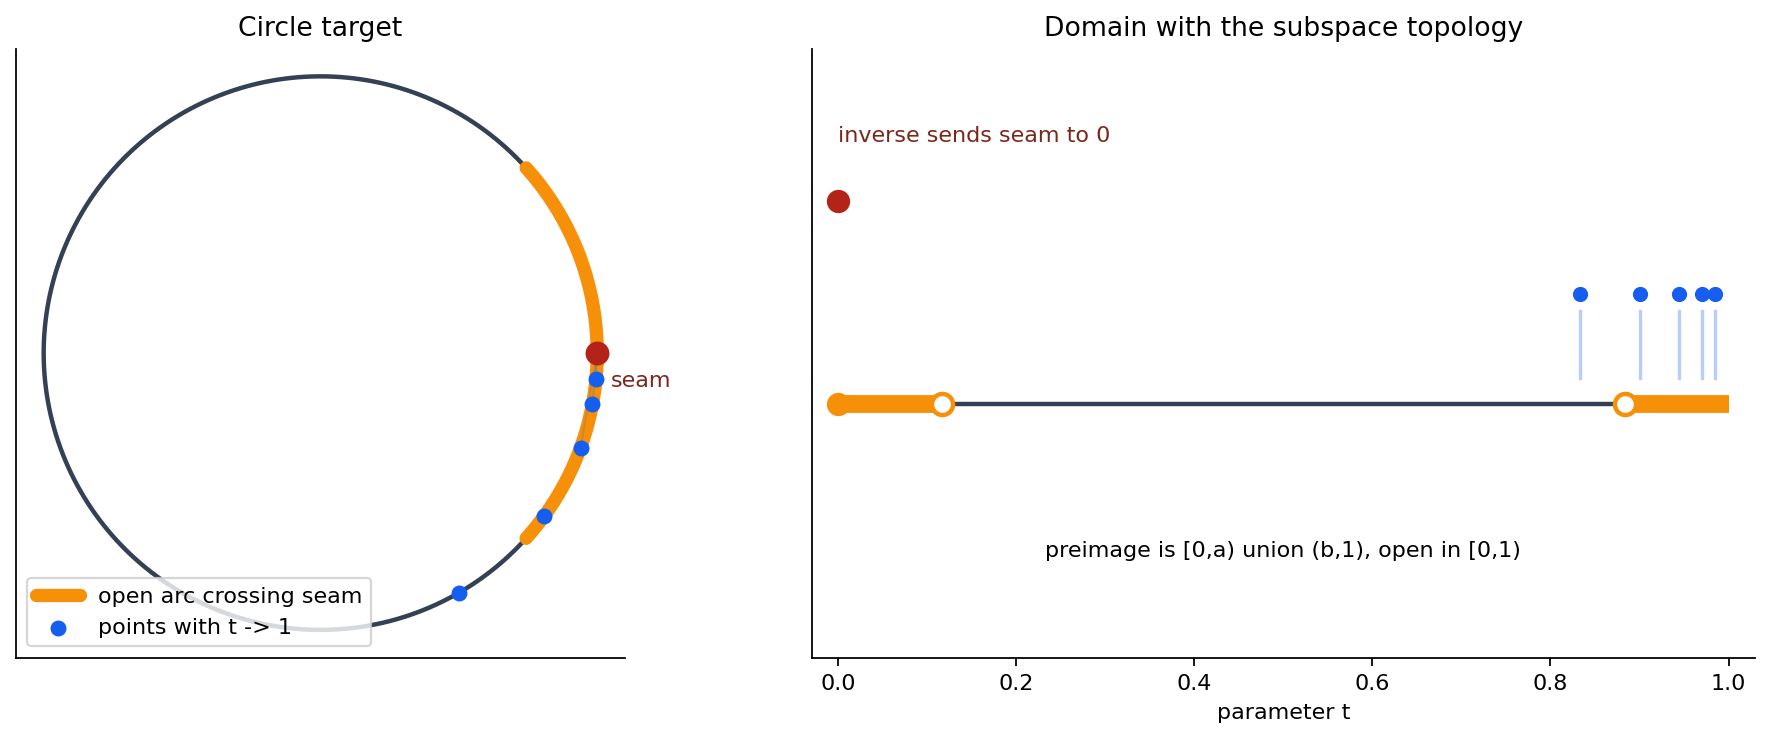

In [4]:
arc = np.deg2rad(42)
a = arc / (2 * np.pi)
b = 1 - a
angles = np.linspace(-arc, arc, 160)
near_seam = np.exp(1j * angles)
seq_ns = np.array([6, 10, 18, 34, 66])
seq_t = 1 - 1 / seq_ns
seq_points = np.exp(2j * np.pi * seq_t)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

ax = axes[0]
ax.plot(np.cos(theta), np.sin(theta), color="#344054", lw=2)
ax.plot(near_seam.real, near_seam.imag, color="#f79009", lw=6, solid_capstyle="round", label="open arc crossing seam")
ax.scatter([1], [0], s=95, color="#b42318", zorder=5)
ax.scatter(seq_points.real, seq_points.imag, color="#155eef", s=38, zorder=6, label="points with t -> 1")
for z in seq_points[-3:]:
    ax.plot([z.real, 1], [z.imag, 0], color="#155eef", alpha=0.18, lw=1)
ax.text(1.05, -0.12, "seam", color="#7a271a")
ax.set_title("Circle target")
ax.set_aspect("equal")
ax.set_xticks([])
ax.set_yticks([])
ax.legend(loc="lower left")

ax = axes[1]
ax.hlines(0, 0, 1, color="#344054", lw=2)
ax.plot([0, a], [0, 0], color="#f79009", lw=8, solid_capstyle="butt")
ax.plot([b, 1], [0, 0], color="#f79009", lw=8, solid_capstyle="butt")
ax.scatter([0], [0], s=90, color="#f79009", zorder=4)
ax.scatter([a, b], [0, 0], s=90, facecolors="white", edgecolors="#f79009", lw=2, zorder=4)
ax.scatter(seq_t, np.full_like(seq_t, 0.13), color="#155eef", s=34, zorder=4)
for t_val in seq_t:
    ax.plot([t_val, t_val], [0.03, 0.11], color="#155eef", alpha=0.3)
ax.scatter([0], [0.24], s=90, color="#b42318")
ax.text(0, 0.31, "inverse sends seam to 0", ha="left", color="#7a271a")
ax.text(0.5, -0.18, "preimage is [0,a) union (b,1), open in [0,1)", ha="center")
ax.set_title("Domain with the subspace topology")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(-0.3, 0.42)
ax.set_yticks([])
ax.set_xlabel("parameter t")

circle_path = save_current_figure("circle-seam-preimage.png")

circle_distances = np.abs(seq_points - 1)
circle_checks = {
    "arc_parameter_a": float(a),
    "arc_parameter_b": float(b),
    "seam_sequence_parameters": [float(v) for v in seq_t],
    "circle_distances_to_seam": [float(v) for v in circle_distances],
    "distances_decrease_toward_zero": bool(np.all(np.diff(circle_distances) < 0)),
    "inverse_parameters_stay_away_from_zero_after_first_sample": bool(np.min(seq_t[1:]) > 0.85),
}
circle_check_path = save_json(circle_checks, UNIT, "checks", "circle-seam-checks.json")
remember(circle_path, 8_000)
remember(circle_check_path, 256)

assert circle_checks["distances_decrease_toward_zero"]
assert circle_checks["inverse_parameters_stay_away_from_zero_after_first_sample"]
assert_artifact(circle_path, min_bytes=artifact_min_bytes[circle_path.as_posix()])
display_artifact(circle_path, width=900)


## Space-Filling Curve Intuition

The source chapter uses a sequence of polygonal approximations whose images become dense in a triangle. The notebook uses Hilbert-style stages in a square because the grid makes the finite computation transparent: at stage `n`, the path visits every one of the `2^n by 2^n` cells, and every point of the square lies within a controlled radius of a visited cell center.

This is only the visual skeleton of the theorem. The later compactness chapter supplies the reason the limiting image is closed, which is the missing ingredient needed to pass from dense image to onto image.


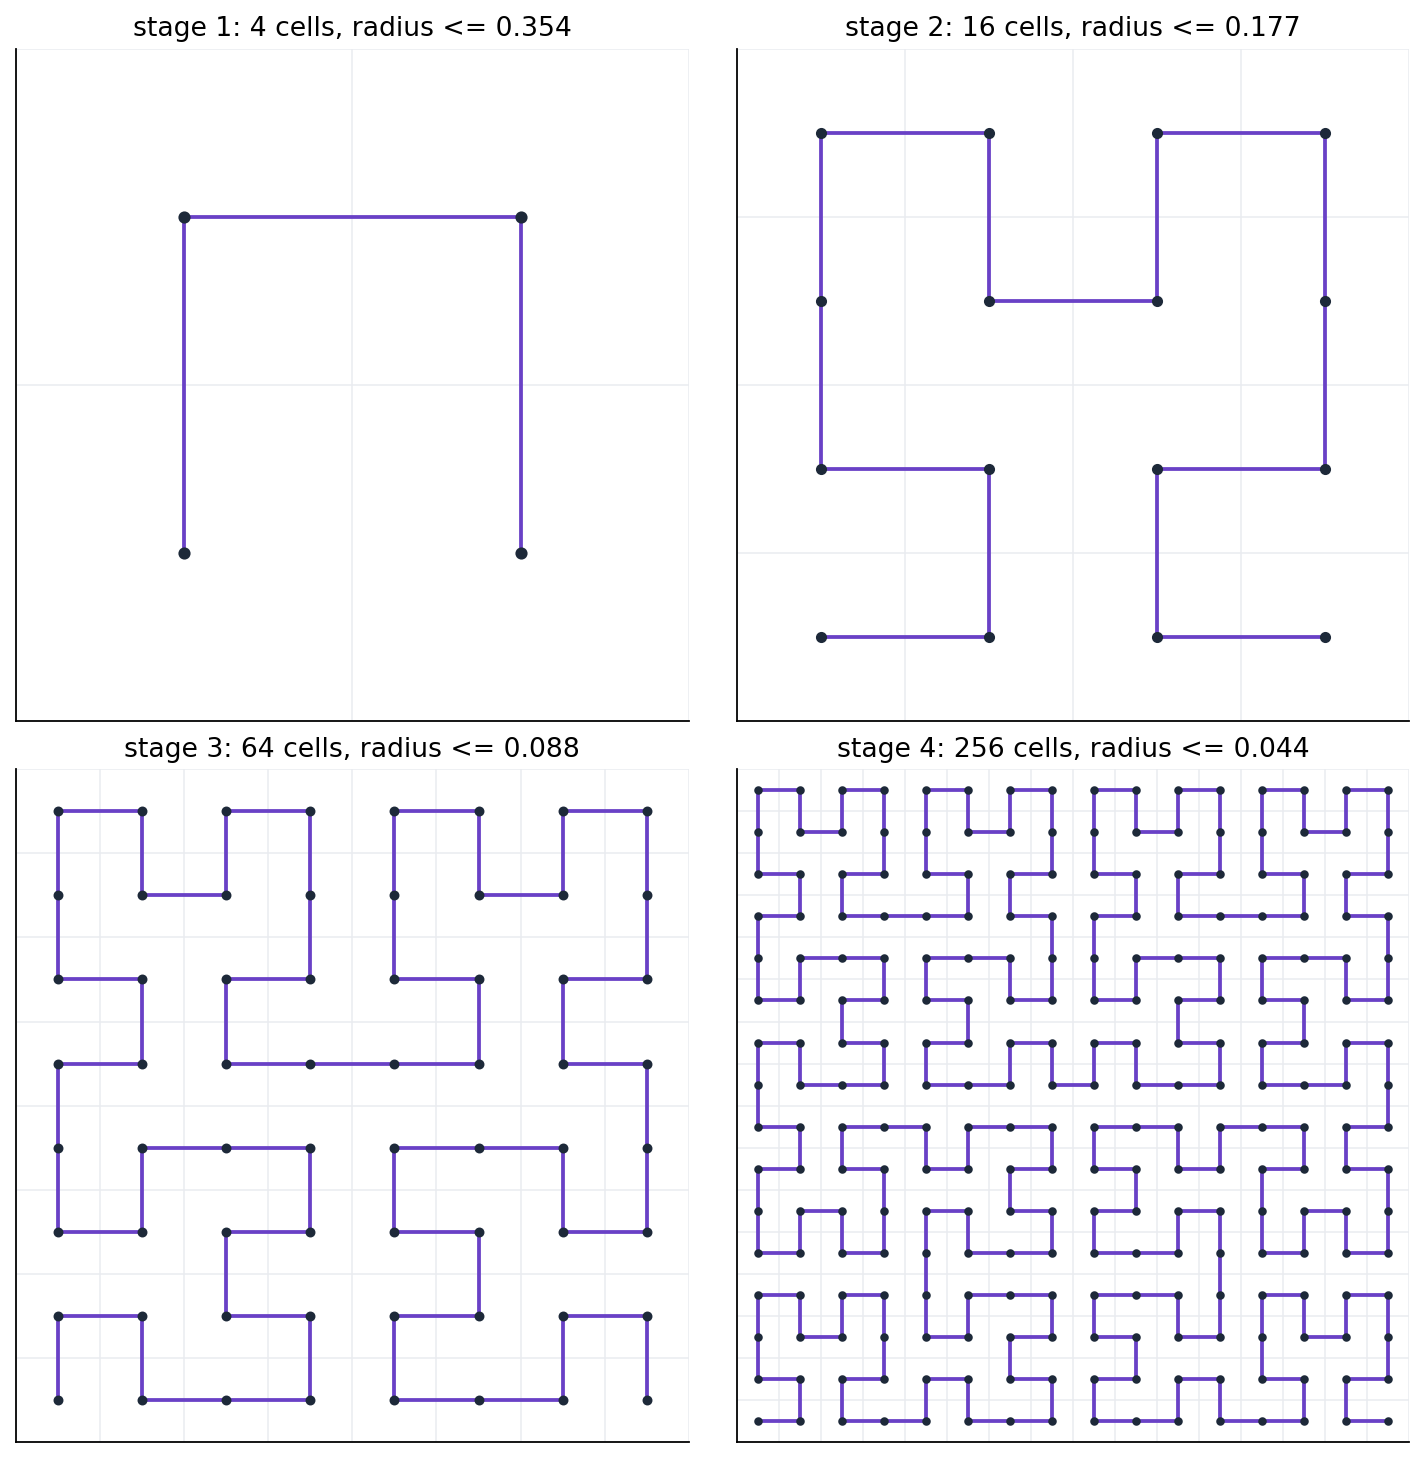

,stage,grid_cells_visited,coverage_radius_bound
0,1,4,0.353553
1,2,16,0.176777
2,3,64,0.088388
3,4,256,0.044194


In [5]:
def hilbert_index_to_xy(order: int, index: int) -> tuple[int, int]:
    x_coord = 0
    y_coord = 0
    t_val = index
    scale = 1
    while scale < 2**order:
        rx = 1 & (t_val // 2)
        ry = 1 & (t_val ^ rx)
        if ry == 0:
            if rx == 1:
                x_coord = scale - 1 - x_coord
                y_coord = scale - 1 - y_coord
            x_coord, y_coord = y_coord, x_coord
        x_coord += scale * rx
        y_coord += scale * ry
        t_val //= 4
        scale *= 2
    return x_coord, y_coord


def hilbert_points(order: int) -> np.ndarray:
    grid = 2**order
    pts = np.array([hilbert_index_to_xy(order, i) for i in range(grid * grid)], dtype=float)
    return (pts + 0.5) / grid


orders = [1, 2, 3, 4]
coverage_rows = []
fig, axes = plt.subplots(2, 2, figsize=(9, 9), constrained_layout=True)
for ax, order in zip(axes.ravel(), orders):
    pts = hilbert_points(order)
    grid = 2**order
    radius = math.sqrt(2) / (2 * grid)
    coverage_rows.append(
        {
            "stage": order,
            "grid_cells_visited": int(grid * grid),
            "coverage_radius_bound": radius,
        }
    )
    for k in range(grid + 1):
        ax.axhline(k / grid, color="#eaecf0", lw=0.7, zorder=0)
        ax.axvline(k / grid, color="#eaecf0", lw=0.7, zorder=0)
    ax.plot(pts[:, 0], pts[:, 1], color="#6941c6", lw=1.7)
    ax.scatter(pts[:, 0], pts[:, 1], s=max(5, 24 - 4 * order), color="#1d2939", zorder=3)
    ax.set_title(f"stage {order}: {grid * grid} cells, radius <= {radius:.3f}")
    ax.set_aspect("equal")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xticks([])
    ax.set_yticks([])

hilbert_path = save_current_figure("space-filling-curve-stage.png")

fig_html = go.Figure()
for order in orders:
    pts = hilbert_points(order)
    fig_html.add_trace(
        go.Scatter(
            x=pts[:, 0],
            y=pts[:, 1],
            mode="lines+markers",
            name=f"stage {order}",
            visible=(order == max(orders)),
            line=dict(width=3),
            marker=dict(size=max(3, 9 - order)),
        )
    )
buttons = []
for i, order in enumerate(orders):
    visible = [False] * len(orders)
    visible[i] = True
    buttons.append(
        dict(
            label=f"stage {order}",
            method="update",
            args=[{"visible": visible}, {"title": f"Hilbert-style finite stage {order}"}],
        )
    )
fig_html.update_layout(
    title="Hilbert-style finite stage 4",
    xaxis=dict(range=[0, 1], constrain="domain"),
    yaxis=dict(range=[0, 1], scaleanchor="x", scaleratio=1),
    width=760,
    height=640,
    updatemenus=[dict(type="buttons", buttons=buttons, x=0.02, y=1.12)],
    margin=dict(l=30, r=20, t=90, b=30),
)
hilbert_html_path = save_plotly_html(fig_html, UNIT, "html", "space-filling-stages.html")
remember(hilbert_path, 8_000)
remember(hilbert_html_path, 8_000)

coverage_table = pd.DataFrame(coverage_rows)
coverage_table_path = artifact_path(UNIT, "tables", "space-filling-coverage.csv")
coverage_table.to_csv(coverage_table_path, index=False)
remember(coverage_table_path, 128)

radii = coverage_table["coverage_radius_bound"].to_numpy()
hilbert_checks = {
    "stages": orders,
    "grid_cells_by_stage": {str(row["stage"]): int(row["grid_cells_visited"]) for row in coverage_rows},
    "coverage_radius_by_stage": {str(row["stage"]): float(row["coverage_radius_bound"]) for row in coverage_rows},
    "coverage_radius_strictly_decreases": bool(np.all(np.diff(radii) < 0)),
    "stage_4_visits_all_16_by_16_cells": int(coverage_rows[-1]["grid_cells_visited"]) == 256,
}
hilbert_check_path = save_json(hilbert_checks, UNIT, "checks", "space-filling-coverage-checks.json")
remember(hilbert_check_path, 256)

assert hilbert_checks["coverage_radius_strictly_decreases"]
assert hilbert_checks["stage_4_visits_all_16_by_16_cells"]
assert_artifact(hilbert_path, min_bytes=artifact_min_bytes[hilbert_path.as_posix()])
assert_artifact(hilbert_html_path, min_bytes=artifact_min_bytes[hilbert_html_path.as_posix()])
display_artifact(hilbert_path, width=760)
display_artifact(hilbert_html_path, width="100%", height=520)
display(coverage_table)


## Restriction, Metric Separation, And Extension

Restrictions are easy because a preimage inside a subspace is just an intersection with that subspace. Extension is harder because values prescribed on a smaller closed set must be continued without breaking continuity.

The Tietze theorem is powered by a metric-space fact: distances to closed sets are continuous. If two closed sets are disjoint, the normalized difference of their distance functions creates a separator that is `1` on one set and `-1` on the other. The lower panel shows a one-dimensional closed-domain function extended across the complementary gaps by ordinary interpolation, a concrete model of what the theorem promises in much greater generality.


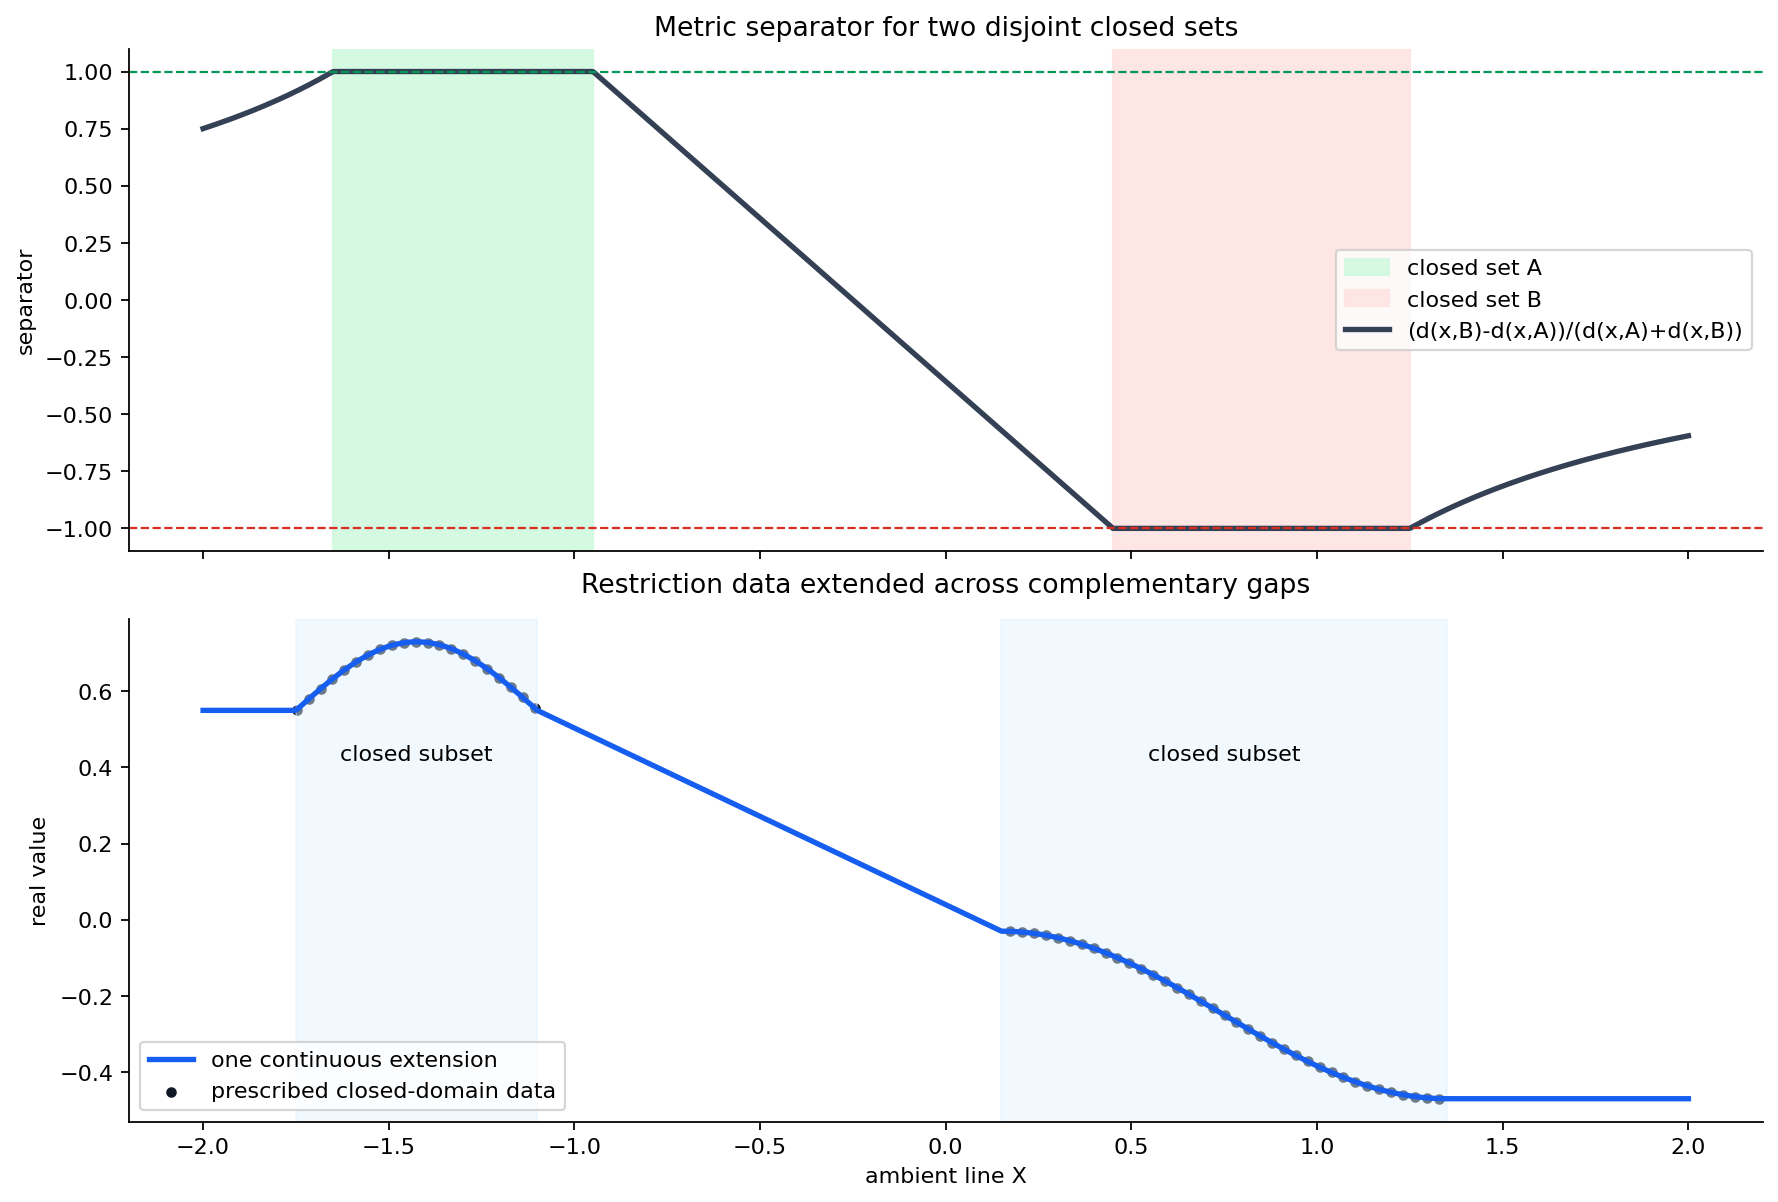

In [6]:
def distance_to_intervals(values: np.ndarray, intervals: list[tuple[float, float]]) -> np.ndarray:
    distances = []
    for left, right in intervals:
        distances.append(
            np.where(
                (values >= left) & (values <= right),
                0.0,
                np.minimum(np.abs(values - left), np.abs(values - right)),
            )
        )
    return np.min(np.vstack(distances), axis=0)


xgrid = np.linspace(-2.0, 2.0, 1000)
A_intervals = [(-1.65, -0.95)]
B_intervals = [(0.45, 1.25)]
dA = distance_to_intervals(xgrid, A_intervals)
dB = distance_to_intervals(xgrid, B_intervals)
separator = (dB - dA) / (dA + dB)

left_interval = (-1.75, -1.1)
right_interval = (0.15, 1.35)


def closed_data(values: np.ndarray) -> np.ndarray:
    out = np.full_like(values, np.nan, dtype=float)
    left_mask = (values >= left_interval[0]) & (values <= left_interval[1])
    right_mask = (values >= right_interval[0]) & (values <= right_interval[1])
    out[left_mask] = 0.55 + 0.18 * np.sin(
        np.pi * (values[left_mask] - left_interval[0]) / (left_interval[1] - left_interval[0])
    )
    out[right_mask] = -0.25 + 0.22 * np.cos(
        np.pi * (values[right_mask] - right_interval[0]) / (right_interval[1] - right_interval[0])
    )
    return out


def explicit_extension(values: np.ndarray) -> np.ndarray:
    left_start, left_end = left_interval
    right_start, right_end = right_interval
    y_left_start = closed_data(np.array([left_start]))[0]
    y_left_end = closed_data(np.array([left_end]))[0]
    y_right_start = closed_data(np.array([right_start]))[0]
    y_right_end = closed_data(np.array([right_end]))[0]
    out = np.empty_like(values, dtype=float)
    out[values < left_start] = y_left_start
    left_mask = (values >= left_start) & (values <= left_end)
    out[left_mask] = closed_data(values[left_mask])
    gap_mask = (values > left_end) & (values < right_start)
    gap_t = (values[gap_mask] - left_end) / (right_start - left_end)
    out[gap_mask] = (1 - gap_t) * y_left_end + gap_t * y_right_start
    right_mask = (values >= right_start) & (values <= right_end)
    out[right_mask] = closed_data(values[right_mask])
    out[values > right_end] = y_right_end
    return out


ext_values = explicit_extension(xgrid)
closed_values = closed_data(xgrid)
closed_mask = ~np.isnan(closed_values)

fig, axes = plt.subplots(2, 1, figsize=(11, 7.4), constrained_layout=True, sharex=True)
ax = axes[0]
for left, right in A_intervals:
    ax.axvspan(left, right, color="#d1fadf", alpha=0.9, label="closed set A")
for left, right in B_intervals:
    ax.axvspan(left, right, color="#fee4e2", alpha=0.9, label="closed set B")
ax.plot(xgrid, separator, color="#344054", lw=2.4, label="(d(x,B)-d(x,A))/(d(x,A)+d(x,B))")
ax.axhline(1, color="#039855", lw=1, ls="--")
ax.axhline(-1, color="#d92d20", lw=1, ls="--")
ax.set_ylabel("separator")
ax.set_title("Metric separator for two disjoint closed sets")
ax.legend(loc="center right")

ax = axes[1]
ax.plot(xgrid, ext_values, color="#155eef", lw=2.4, label="one continuous extension")
ax.scatter(xgrid[closed_mask][::8], closed_values[closed_mask][::8], color="#101828", s=14, label="prescribed closed-domain data")
ax.axvspan(left_interval[0], left_interval[1], color="#e0f2fe", alpha=0.45)
ax.axvspan(right_interval[0], right_interval[1], color="#e0f2fe", alpha=0.45)
ax.text((left_interval[0] + left_interval[1]) / 2, 0.42, "closed subset", ha="center")
ax.text((right_interval[0] + right_interval[1]) / 2, 0.42, "closed subset", ha="center")
ax.set_xlabel("ambient line X")
ax.set_ylabel("real value")
ax.set_title("Restriction data extended across complementary gaps", pad=12)
ax.legend(loc="lower left")

extension_path = save_current_figure("metric-separation-extension.png")

n = sp.symbols("n", integer=True, positive=True)
tietze_series_sum = sp.summation(sp.Rational(2, 1) ** (n - 1) / sp.Rational(3, 1) ** n, (n, 1, sp.oo))
A_mask = (xgrid >= A_intervals[0][0]) & (xgrid <= A_intervals[0][1])
B_mask = (xgrid >= B_intervals[0][0]) & (xgrid <= B_intervals[0][1])
separator_checks = {
    "separator_max_error_on_A": float(np.max(np.abs(separator[A_mask] - 1))),
    "separator_max_error_on_B": float(np.max(np.abs(separator[B_mask] + 1))),
    "distance_to_A_adjacent_lipschitz_ok": bool(np.all(np.abs(np.diff(dA)) <= np.diff(xgrid) + 1e-12)),
    "extension_agrees_with_closed_data_max_error": float(np.nanmax(np.abs(ext_values[closed_mask] - closed_values[closed_mask]))),
    "tietze_geometric_majorant_sum": str(tietze_series_sum),
}
extension_check_path = save_json(separator_checks, UNIT, "checks", "metric-separation-extension-checks.json")
remember(extension_path, 8_000)
remember(extension_check_path, 128)

assert separator_checks["separator_max_error_on_A"] < 1e-12
assert separator_checks["separator_max_error_on_B"] < 1e-12
assert separator_checks["distance_to_A_adjacent_lipschitz_ok"]
assert separator_checks["extension_agrees_with_closed_data_max_error"] < 1e-12
assert tietze_series_sum == 1
assert_artifact(extension_path, min_bytes=artifact_min_bytes[extension_path.as_posix()])
display_artifact(extension_path, width=850)


## Applied Lab: Tune A Preimage Test And A Separator

The lab changes the target band for `x^2` and measures the open preimage components. It also reports the minimum gap between the two closed sets used in the separator. The important habit is to describe the preimage in the domain before deciding whether the original map passed the continuity test.


In [7]:
def square_preimage_components(low: float, high: float, domain_radius: float = 2.0) -> list[tuple[float, float]]:
    if low < 0 or high <= low:
        raise ValueError("Use a target band 0 <= low < high for this lab.")
    outer = min(math.sqrt(high), domain_radius)
    inner = min(math.sqrt(low), domain_radius)
    components: list[tuple[float, float]] = []
    if inner < outer:
        components.append((-outer, -inner))
        if inner == 0:
            components.append((0.0, outer))
        else:
            components.append((inner, outer))
    return components


lab_bands = [(0.05, 0.45), (0.25, 1.00), (0.75, 1.80)]
lab_rows = []
for low, high in lab_bands:
    components = square_preimage_components(low, high)
    total_length = sum(b - a for a, b in components)
    lab_rows.append(
        {
            "target_band": f"({low}, {high})",
            "component_count": len(components),
            "components_in_domain": json.dumps([[round(a, 4), round(b, 4)] for a, b in components]),
            "total_preimage_length_in_[-2,2]": round(total_length, 6),
        }
    )

minimum_closed_set_gap = B_intervals[0][0] - A_intervals[0][1]
lab_table = pd.DataFrame(lab_rows)
lab_table["separator_closed_set_gap"] = minimum_closed_set_gap
lab_table_path = artifact_path(UNIT, "tables", "applied-lab-preimage-components.csv")
lab_table.to_csv(lab_table_path, index=False)
remember(lab_table_path, 128)

lab_checks = {
    "band_count": len(lab_bands),
    "all_preimages_have_two_components": bool(all(row["component_count"] == 2 for row in lab_rows)),
    "separator_closed_set_gap": float(minimum_closed_set_gap),
    "gap_is_positive": bool(minimum_closed_set_gap > 0),
}
lab_check_path = save_json(lab_checks, UNIT, "checks", "applied-lab-checks.json")
remember(lab_check_path, 128)

assert lab_checks["all_preimages_have_two_components"]
assert lab_checks["gap_is_positive"]
assert_artifact(lab_table_path, min_bytes=artifact_min_bytes[lab_table_path.as_posix()])
display(lab_table)


,target_band,component_count,components_in_domain,"total_preimage_length_in_[-2,2]",separator_closed_set_gap
0,"(0.05, 0.45)",2,"[[-0.6708, -0.2236], [0.2236, 0.6708]]",0.894427,1.4
1,"(0.25, 1.0)",2,"[[-1.0, -0.5], [0.5, 1.0]]",1.000000,1.4
2,"(0.75, 1.8)",2,"[[-1.3416, -0.866], [0.866, 1.3416]]",0.951231,1.4


## Final Sanity Checks

The final cell checks the artifacts as course-local evidence, then rechecks the mathematical claims that the figures depend on: exact preimage inequalities, the Hilbert coverage decay, the circle seam sequence, the separator values, and the extension agreement.


In [8]:
for path in created_artifacts:
    assert_artifact(path, min_bytes=artifact_min_bytes[path.as_posix()])

for image_path in [p for p in created_artifacts if p.suffix.lower() == ".png"]:
    pixels = np.asarray(Image.open(image_path).convert("L"), dtype=float)
    assert pixels.std() > 2.0, f"{image_path} appears nearly blank"

check_files = sorted((BOOK_ROOT / "artifacts" / UNIT / "checks").glob("*.json"))
check_payloads = {path.name: json.loads(path.read_text(encoding="utf-8")) for path in check_files}

assert check_payloads["preimage-continuity-checks.json"]["theorem_cycle_strongly_connected"]
assert check_payloads["space-filling-coverage-checks.json"]["coverage_radius_strictly_decreases"]
assert check_payloads["circle-seam-checks.json"]["distances_decrease_toward_zero"]
assert check_payloads["metric-separation-extension-checks.json"]["distance_to_A_adjacent_lipschitz_ok"]
assert check_payloads["applied-lab-checks.json"]["gap_is_positive"]

summary = pd.DataFrame(
    [
        {
            "artifact": path.relative_to(BOOK_ROOT).as_posix(),
            "bytes": path.stat().st_size,
            "kind": path.suffix.lower().lstrip("."),
        }
        for path in created_artifacts
    ]
).sort_values(["kind", "artifact"])
summary


,artifact,bytes,kind
19,artifacts/chapter-02/tables/applied-lab-preima...,304,csv
1,artifacts/chapter-02/tables/open-closed-fronti...,309,csv
14,artifacts/chapter-02/tables/space-filling-cove...,150,csv
13,artifacts/chapter-02/html/space-filling-stages...,17413,html
20,artifacts/chapter-02/checks/applied-lab-checks...,133,json
10,artifacts/chapter-02/checks/circle-seam-checks...,514,json
18,artifacts/chapter-02/checks/metric-separation-...,219,json
2,artifacts/chapter-02/checks/open-closed-fronti...,195,json
7,artifacts/chapter-02/checks/preimage-continuit...,343,json
15,artifacts/chapter-02/checks/space-filling-cove...,397,json


## Takeaways

- Open sets encode the local room required for neighborhoods; closed sets encode which limit points cannot be omitted.
- Continuity is best tested by inverse images. A single target open set with a non-open preimage is enough to disprove continuity.
- A continuous bijection need not be a homeomorphism. The interval-to-circle seam shows that the inverse topology matters.
- Space-filling approximations show how a one-dimensional parameter can get arbitrarily close to every point of a two-dimensional region; the onto conclusion needs the closed-image results from compactness.
- Metric distance functions are topological tools. They separate disjoint closed sets and form the mechanism behind extension theorems such as Tietze.
